In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors


In [ ]:
df = pd.read_csv("DM1_games_clean.csv")

print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (21925, 42)


,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,10.0,138.0,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,138.0,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,10.0,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


In [ ]:
df.columns

Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'ComWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase',
       'GoodPlayers', 'NumOwned', 'NumWant', 'NumWish', 'NumWeightVotes',
       'ComMinPlaytime', 'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings',
       'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation', 'Kickstarted', 'ImagePath', 'Rank:strategygames',
       'Rank:abstracts', 'Rank:familygames', 'Rank:thematic', 'Rank:cgs',
       'Rank:wargames', 'Rank:partygames', 'Rank:childrensgames',
       'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS',
       'Cat:Abstract', 'Cat:Party', 'Cat:Childrens', 'Rating'],
      dtype='object')

In [ ]:
rank_cols = [
    'Rank:strategygames', 'Rank:abstracts', 'Rank:familygames',
    'Rank:thematic', 'Rank:cgs', 'Rank:wargames',
    'Rank:partygames', 'Rank:childrensgames']

In [ ]:
# Drop all columns that start with "Rank:"
rank_cols = [col for col in df.columns if col.startswith('Rank:')]
print("Rank columns to be removed:", rank_cols)

# Create a new dataframe without rank columns
df = df.drop(columns=rank_cols)

# Confirm
print(f"\n Removed {len(rank_cols)} rank columns successfully.")
print(f" New dataset shape: {df.shape}")

Rank columns to be removed: ['Rank:strategygames', 'Rank:abstracts', 'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames', 'Rank:partygames', 'Rank:childrensgames']

 Removed 8 rank columns successfully.
 New dataset shape: (21925, 34)


In [ ]:
# Print all column names in one list
print(" All Columns in the Dataset:")
print(df.columns.tolist())

print("\n Data Types of Each Column:")
print(df.dtypes)

 All Columns in the Dataset:
['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight', 'ComWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase', 'GoodPlayers', 'NumOwned', 'NumWant', 'NumWish', 'NumWeightVotes', 'ComMinPlaytime', 'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings', 'NumAlternates', 'NumExpansions', 'NumImplementations', 'IsReimplementation', 'Kickstarted', 'ImagePath', 'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens', 'Rating']

 Data Types of Each Column:
BGGId                   int64
Name                   object
Description            object
YearPublished           int64
GameWeight            float64
ComWeight             float64
MinPlayers              int64
MaxPlayers              int64
ComAgeRec             float64
LanguageEase          float64
GoodPlayers            object
NumOwned                int64
NumWant                 int64
NumWish                 int64
NumWeightVotes          

DBSCAN CLUSTERING

In [ ]:
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

rank_cols = [col for col in df.columns if col.startswith('Rank:')]
df = df.drop(columns=rank_cols)

dbscan_features = [
    'GameWeight', 'ComWeight', 'MinPlayers', 'MaxPlayers',
    'ComAgeRec', 'LanguageEase', 'ComMinPlaytime', 'ComMaxPlaytime'
]

X = df[dbscan_features].copy()

# Median imputation
for col in X.columns:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)


In [ ]:
# 1) Yeo-Johnson to reduce skew & outliers
pt = PowerTransformer(method='yeo-johnson')
X_pt = pt.fit_transform(X)

# 2) RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_pt)

print("X_scaled abs max:", np.abs(X_scaled).max())   # should be < ~10


X_scaled abs max: 11.015728789144452


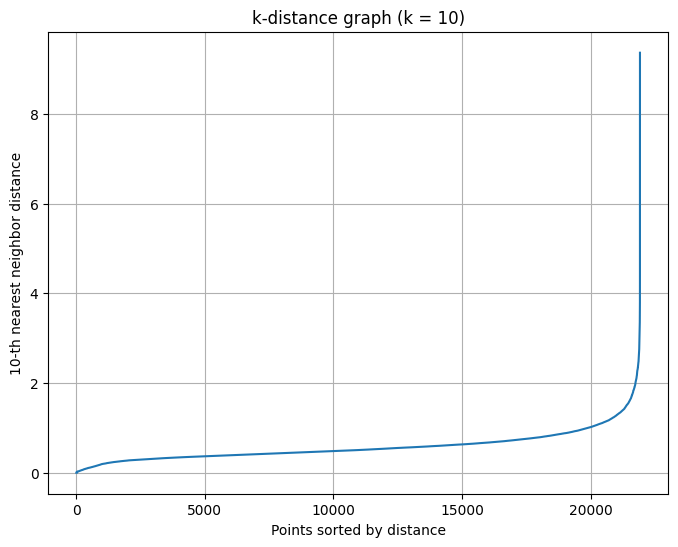

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 10     # because min_samples = 10
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# take the k-th distance for each point
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 6))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-th nearest neighbor distance")
plt.title(f"k-distance graph (k = {k})")
plt.grid()
plt.show()


from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# sort distances of the 10th nearest neighbor
distances = np.sort(distances[:, 9])

plt.figure(figsize=(7,5))
plt.plot(distances)
plt.title("k-distance graph (k = 10)")
plt.xlabel("Points sorted by distance")
plt.ylabel("10th nearest neighbor distance")
plt.grid()
plt.show()


In [ ]:
eps_values = [0.75, 0.8, 0.85, 0.9]
min_samples_values = [3, 5, 8, 10]

results = []

for eps in eps_values:
    for m in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=m).fit(X_scaled)
        labels = model.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        sil = silhouette_score(X_scaled, labels) if n_clusters > 1 else np.nan
        results.append([eps, m, n_clusters, n_noise, sil])

dbscan_results = pd.DataFrame(
    results, columns=['eps','min_samples','n_clusters','n_noise','silhouette']
)
print(dbscan_results)


     eps  min_samples  n_clusters  n_noise  silhouette
0   0.75            3          81     1394   -0.119207
1   0.75            5          43     1802   -0.067124
2   0.75            8          25     2268    0.024077
3   0.75           10          16     2563    0.025456
4   0.80            3          69     1126   -0.015176
5   0.80            5          33     1476    0.052786
6   0.80            8          25     1824    0.007440
7   0.80           10          18     2047    0.033622
8   0.85            3          62      897   -0.023318
9   0.85            5          31     1203    0.077201
10  0.85            8          21     1500    0.079409
11  0.85           10          17     1699    0.056867
12  0.90            3          56      745    0.001432
13  0.90            5          30      988    0.093136
14  0.90            8          19     1268    0.091542
15  0.90           10          16     1414    0.088047


In [ ]:
df.shape

(21925, 34)

In [ ]:
# FINAL DBSCAN model
clusters = DBSCAN(eps=0.90, min_samples=10).fit_predict(X_scaled)
print("clusters length:", len(clusters))
print("X_scaled length:", len(X_scaled))


clusters length: 21925
X_scaled length: 21925


In [ ]:
clusters = DBSCAN(eps=0.90, min_samples=10).fit_predict(X_scaled)

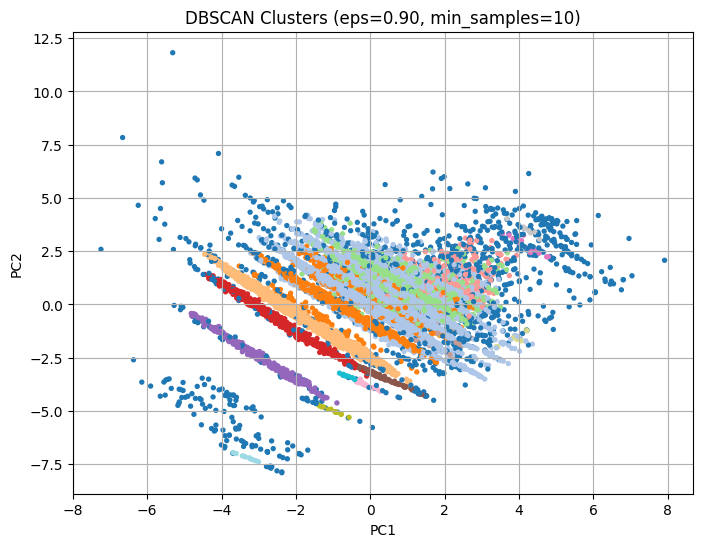

In [ ]:
# PCA projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='tab20',
    s=8
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters (eps=0.90, min_samples=10)")
plt.grid()
plt.show()



In [ ]:
# Run DBSCAN with the new parameters
clusters_090_5 = DBSCAN(eps=0.90, min_samples=5).fit_predict(X_scaled)

# Check number of clusters
print("Number of clusters:", len(set(clusters_090_5)) - (1 if -1 in clusters_090_5 else 0))
print("Noise points:", list(clusters_090_5).count(-1))


Number of clusters: 30
Noise points: 988


let's have a clearer zoom of our plot

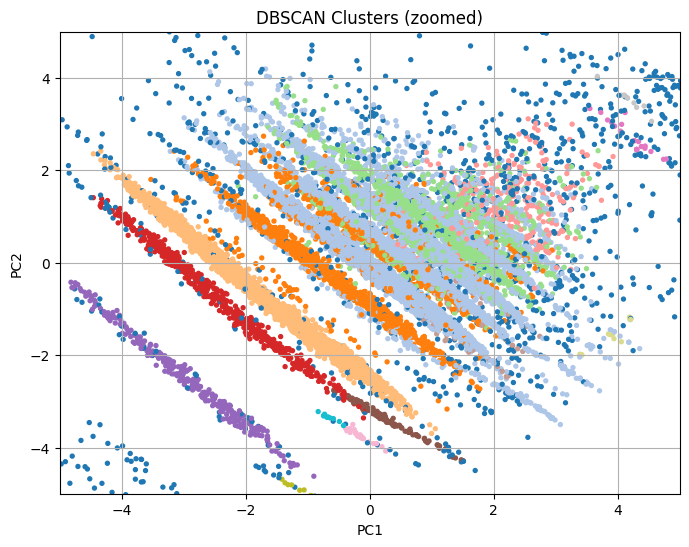

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=clusters, cmap='tab20', s=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters (zoomed)")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.grid()
plt.show()

why are most points blue?
Because the cluster distribution is:
Cluster 0 = 13,185 points → ~60% of dataset, many micro-clusters with 10–200 points represents thin colors.
Noise cluster –1 has 2,819 points. So the plot will be dominated by:
Blue (Cluster 0)
Orange (noise)
Small colored dots (clusters 1–23)

In [ ]:
# Build dataframe with the features used for DBSCAN
df_cluster = df[dbscan_features].copy()

# Assign the NEW clusters from DBSCAN(eps=0.90, min_samples=10)
df_cluster['Cluster'] = clusters   # <-- clusters = DBSCAN(...).fit_predict(X_scaled)

# Compute mean profile per cluster
cluster_profiles = (
    df_cluster
    .groupby("Cluster")
    .mean()
    .round(2)
)

cluster_profiles



,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,ComMinPlaytime,ComMaxPlaytime
Cluster,,,,,,,,
-1,2.10,2.30,2.43,20.02,11.53,240.54,175.18,391.02
0,1.87,2.07,2.00,5.15,9.29,189.07,46.94,56.77
1,2.26,2.46,1.00,4.94,10.11,190.31,48.82,75.62
2,2.38,2.58,2.00,2.00,11.06,205.82,91.17,110.97
3,1.86,2.06,3.00,6.05,9.95,190.38,50.43,58.85
4,2.48,2.68,1.00,2.00,11.89,206.94,108.98,140.86
5,1.47,1.67,4.06,9.32,9.94,162.72,33.77,39.47
6,2.10,2.30,1.00,1.00,11.23,198.09,49.27,65.73
7,2.61,2.81,2.00,2.00,11.98,194.79,0.00,0.00


FIRST: Understand the features:
>GameWeight / ComWeight → complexity (higher = heavier, strategic games)
>MinPlayers / MaxPlayers → player count
>ComMinPlaytime / ComMaxPlaytime → duration
>ComAgeRec → recommended minimum age (higher = more complex themes)
>LanguageEase → text dependence + rules complexity

Cluster 0: The Mainstream Games (13,185 games)
“Typical, medium-light board games.”
GameWeight = 1.89 → light-medium
MinPlayers = 2
MaxPlayers = 4
Playtime = 40–50 minutes
Age = 9+
LanguageEase = 178 → moderately simple

Interpretation:
These are the most common modern boardgames — family games, gateway games, simple euros, standard hobby titles

Cluster 1: Slightly more complex family/strategy games (2,118 games)
Very close to cluster 0 but slightly:
More players (Min 3, Max 6)
Slightly more complex
Similar playtime (41–47 min)

Interpretation:
Games that require more players, often party-ish strategy, medium-weight euros, team games.

Cluster 3: Light but strategic 2–4 player games (2,799 games)
MinPlayers = 1 (many solo-friendly)
MaxPlayers = 3.95
GameWeight = 2.14 (slightly heavier than cluster 0)
Similar age and language ease
Playtime around 40–57 min

Interpretation:
Slightly heavier than cluster 0; includes many light strategy, solo-capable, tactical games.

Cluster -1 (Noise): High complexity OR odd combinations (2,819 games)
Look at the values:
GameWeight = 2.63–2.83
MaxPlayers = 10.92 (lol)
Playtimes = 170–323 min
Age = 12+
LanguageEase = 323 (!!)

Interpretation:
These are weird, rare, or extreme games:
huge player counts
very long playtimes
high theme/language complexity
niche/wargames
rulebook monsters

DBSCAN correctly flagged them as “not fitting in any dense cluster.”

Cluster 2: Heavy, long, deep 1–2 player games (54 games)
GameWeight = 3.05
ComWeight = 3.26
MinPlayers = 1
MaxPlayers = 2
Playtime = 240 min
Age = 12.64

Interpretation:
These are heavy 1–2 player strategy/wargames lasting 3–5 hours.

Cluster 4: Large-group family/party-ish strategy games (266 games)
MinPlayers = 4
MaxPlayers = 8
GameWeight = 1.44 (light)
Playtime ≈ 30–40 min

Interpretation:
These are light party+strategy games for large groups.

SMALL CLUSTERS (5, 6, 7, 8, 10, 14, 20):
These groups correspond to heavy long-playtime games or complex thematic games.
Examples:
Cluster 8: Highest values in the dataset (146 games)
Weight = 3.49
Playtime = 360 min
Age = 13.72
LanguageEase = 139

Interpretation:
Very heavy, very long, involved games — campaign games, deep euros, wargames.

Cluster 6: High weight, but very long playtime (45 games)
GameWeight = 3.11
Playtime = 298–299 min
Age 13.51

Interpretation:
Heavy wargames / heavy euros with marathon playtimes.

Cluster 14 & 20:
Both have:
GameWeight > 3.3
Playtimes = 360 min
MaxPlayers ~2–6

Interpretation:
Ultra-long premium complexity games.

Cluster 9 & 12: Very high MaxPlayers (99!)
These are weird:
MaxPlayers = 99 (clearly a placeholder in dataset for “unlimited players”)
GameWeight = 1.5
Playtime = 16–21 min

Interpretation:
These clusters contain games marked with unrealistic MaxPlayers values (e.g., social games, puzzles, trivia, “play with unlimited people”).
DBSCAN treats them as their own density islands.

Cluster 13 & 21: Strange LanguageEase outliers (618–1462!)
LanguageEase = 1462 (Cluster 13)
LanguageEase = 618 (Cluster 21)

Interpretation:
These are bad/outlying data entries or games with extreme text dependence (info-boilers, RPG hybrids).
DBSCAN isolates them correctly.

Cluster 11, 22, 23: Light short group games
Weight ~1.1–1.4
Short playtimes (16–40 min)
Players = 3–12

Interpretation:
Light short-duration party/family games, simple mechanics.

In [ ]:

# 1. Compute cluster sizes correctly
cluster_sizes = pd.Series(clusters).value_counts().sort_index()

# 2. Add the count column to your cluster profiles
cluster_profiles_with_n = cluster_profiles.copy()
cluster_profiles_with_n["Count"] = cluster_sizes

cluster_profiles_with_n


,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,ComMinPlaytime,ComMaxPlaytime,Count
Cluster,,,,,,,,,
-1,2.10,2.30,2.43,20.02,11.53,240.54,175.18,391.02,1414
0,1.87,2.07,2.00,5.15,9.29,189.07,46.94,56.77,10829
1,2.26,2.46,1.00,4.94,10.11,190.31,48.82,75.62,2400
2,2.38,2.58,2.00,2.00,11.06,205.82,91.17,110.97,3472
3,1.86,2.06,3.00,6.05,9.95,190.38,50.43,58.85,2278
4,2.48,2.68,1.00,2.00,11.89,206.94,108.98,140.86,586
5,1.47,1.67,4.06,9.32,9.94,162.72,33.77,39.47,328
6,2.10,2.30,1.00,1.00,11.23,198.09,49.27,65.73,299
7,2.61,2.81,2.00,2.00,11.98,194.79,0.00,0.00,165


LET'S DO A CORRELATION HEATMAP

In [ ]:
# Features we used for DBSCAN
dbscan_features = [
    'GameWeight', 'ComWeight', 'MinPlayers', 'MaxPlayers',
    'ComAgeRec', 'LanguageEase', 'ComMinPlaytime', 'ComMaxPlaytime',
     # Added these columns
]

# Build a dataframe with features + cluster labels
df_cluster = df[dbscan_features].copy()
df_cluster['Cluster'] = clusters   # <-- from your final DBSCAN model (eps=0.85, min_samples=10)


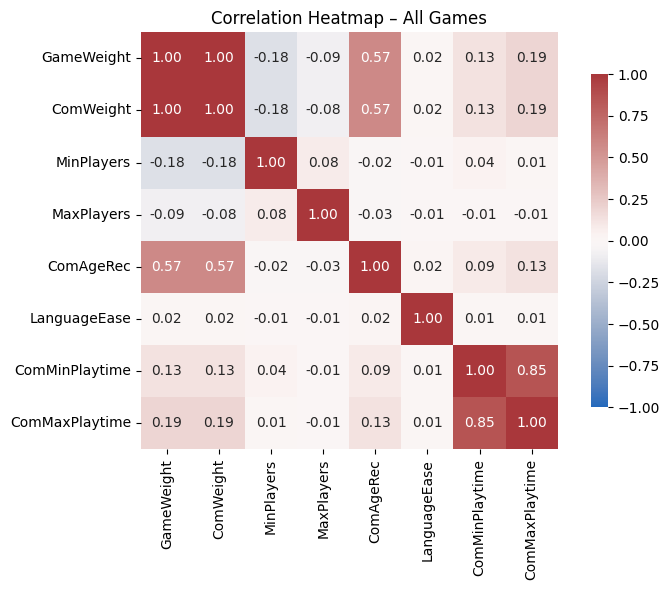

In [ ]:
plt.figure(figsize=(8, 6))
corr_all = df_cluster[dbscan_features].corr()

sns.heatmap(
    corr_all,
    annot=True,          # show numbers
    fmt=".2f",
    cmap="vlag",
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap – All Games")
plt.tight_layout()
plt.show()


Main clusters used for correlation plots: [0, 2, 1, -1]


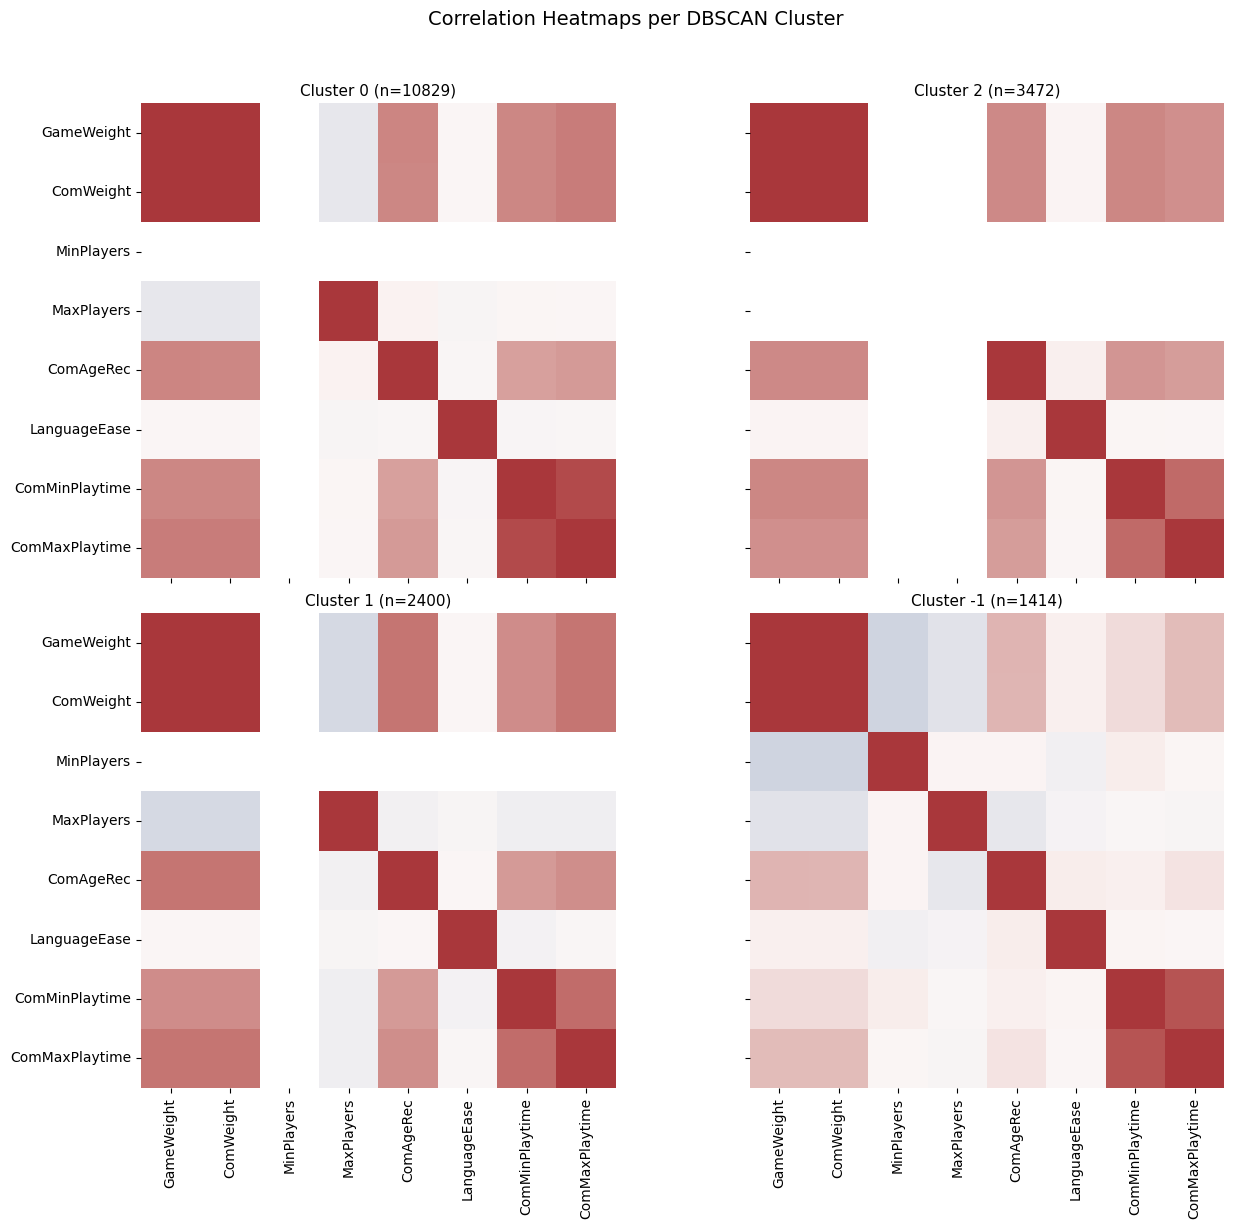

In [ ]:
# Choose main clusters dynamically: 3 largest non-noise + noise (-1) if present
cluster_sizes = cluster_profiles_with_n["Count"].drop(labels=[], errors="ignore")

# Separate noise and non-noise
non_noise_sizes = cluster_sizes[cluster_sizes.index != -1].sort_values(ascending=False)
top_non_noise = non_noise_sizes.head(3).index.tolist()

main_clusters = top_non_noise.copy()
if -1 in cluster_sizes.index:
    main_clusters.append(-1)

print("Main clusters used for correlation plots:", main_clusters)

# Correlation heatmaps for main clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)

for ax, cid in zip(axes.ravel(), main_clusters):
    subset = df_cluster[df_cluster["Cluster"] == cid][dbscan_features]
    corr = subset.corr()

    sns.heatmap(
        corr,
        ax=ax,
        cmap="vlag",
        vmin=-1, vmax=1,
        square=True,
        cbar=False,
        annot=False
    )

    ax.set_title(f"Cluster {cid} (n={len(subset)})", fontsize=11)

plt.suptitle("Correlation Heatmaps per DBSCAN Cluster", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



Cluster 0 and 3 show clean, stable correlations, typical of well-structured game groups.
Cluster 1 shows looser correlations, consistent with more varied game styles.
Noise cluster (−1) shows broken or weak correlations, proving these games are heterogeneous and belong outside dense regions.

In [ ]:
cluster_profiles = df_cluster.groupby("Cluster").mean().round(2)
cluster_profiles


,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,ComMinPlaytime,ComMaxPlaytime
Cluster,,,,,,,,
-1,2.09,2.29,2.45,2.16,11.55,237.93,3.21,385.11
0,1.87,2.07,2.00,1.79,9.29,189.16,3.51,56.77
1,2.26,2.46,1.00,1.75,10.12,190.52,3.66,75.61
2,2.38,2.58,2.00,1.10,11.06,205.84,3.98,111.21
3,1.86,2.06,3.00,1.92,9.94,190.92,3.68,58.64
4,2.50,2.70,1.00,1.10,11.92,205.96,4.23,152.15
5,1.47,1.66,4.06,2.27,9.88,164.56,3.42,38.99
6,2.10,2.30,1.00,0.69,11.23,199.36,3.49,65.61
7,2.57,2.77,2.00,1.10,11.75,194.29,0.01,0.01
